In [ ]:
"First upload the pkl files in google colab and after that run it"

def fetch_realtime_kolkata():
    """
    Fetch CURRENT real-time conditions from OpenWeatherMap.
    No lag — actual current hour data.
    Free tier: 60 calls/min, 1M calls/month.
    Get API key free at: openweathermap.org/api
    """
    OWM_API_KEY = '59a2e9f07edc1cab2cdf70f7bd3955b2'

    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {
        "lat"   : 22.5726,
        "lon"   : 88.3639,
        "appid" : OWM_API_KEY,
        "units" : "metric",
    }

    r    = requests.get(url, params=params, timeout=10)
    r.raise_for_status()
    data = r.json()

    temp_c    = data['main']['temp']
    rh_pct    = data['main']['humidity']
    press_hpa = data['main']['pressure']
    # OWM gives rain in last 1hr or 3hr
    rain_mm   = data.get('rain', {}).get('1h', 0.0)

    return {
        'time'     : now_ist(),
        'Temp_C'   : temp_c,
        'RH_pct'   : rh_pct,
        'Press_hPa': press_hpa,
        'Rain_mm'  : rain_mm,
    }
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import requests
import pandas as pd
import numpy as np
import joblib
from datetime import datetime, timezone, timedelta

# IST defined once, used everywhere
IST = timezone(timedelta(hours=5, minutes=30))

def now_ist():
    """Always returns current IST time as naive timestamp."""
    return pd.Timestamp.now(tz=IST).replace(tzinfo=None)

print(f"Current IST : {now_ist().strftime('%d %b %Y  %H:%M')}")


# ── Cell 2: Load Models ───────────────────────────────────────────────────────
stage1    = joblib.load('stage1_classifier.pkl')
stage2    = joblib.load('stage2_regressor.pkl')
feat_cols = joblib.load('feature_cols.pkl')
config    = joblib.load('model_config.pkl')
THRESHOLD = config['threshold']

print(f"Models loaded successfully")
print(f"  Trained on  : {config['trained_on']}")
print(f"  Features    : {config['n_features']}")
print(f"  Threshold   : {THRESHOLD:.4f}")


# ── Cell 3: RH → Specific Humidity conversion ─────────────────────────────────
def rh_to_specific_humidity(rh_pct, temp_c, press_hpa):
    """
    Convert relative humidity (%) → specific humidity (kg/kg)
    using August-Roche-Magnus formula.
    Matches the conversion used internally by NASA MERRA-2.
    """
    e_sat = 6.112 * np.exp((17.67 * temp_c) / (temp_c + 243.5))
    e_act = (rh_pct / 100.0) * e_sat
    q     = (0.622 * e_act) / (press_hpa - 0.378 * e_act)
    return q


# ── Cell 4: Fetch Data from Open-Meteo ───────────────────────────────────────
def fetch_recent_kolkata_realtime(days_back=7):
    """
    Hybrid fetch:
    - Past 7 days history   : Open-Meteo (lag OK for history)
    - Current hour          : OpenWeatherMap (real-time, no lag)
    """
    # ── Past history from Open-Meteo ──────────────────────────────────────────
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude"     : 22.5726,
        "longitude"    : 88.3639,
        "hourly"       : ",".join([
            "temperature_2m",
            "relative_humidity_2m",
            "surface_pressure",
            "precipitation",
        ]),
        "past_days"    : days_back,
        "forecast_days": 1,
        "timezone"     : "Asia/Kolkata",
    }
    r    = requests.get(url, params=params, timeout=10)
    r.raise_for_status()
    data = r.json()['hourly']

    df = pd.DataFrame({
        'time'     : pd.to_datetime(data['time']),
        'Temp_C'   : data['temperature_2m'],
        'RH_pct'   : data['relative_humidity_2m'],
        'Press_hPa': data['surface_pressure'],
        'Rain_mm'  : data['precipitation'],
    })

    current_ist = now_ist()
    df = df[df['time'] <= current_ist].copy()
    df.loc[df['time'] > current_ist, 'Rain_mm'] = 0.0

    # ── Append real-time current row from OpenWeatherMap ─────────────────────
    try:
        rt = fetch_realtime_kolkata()

        # Round current IST down to nearest hour
        current_hour = current_ist.floor('h')

        # Remove any existing row for this hour from Open-Meteo
        df = df[df['time'] < current_hour].copy()

        # Append fresh real-time row
        new_row = pd.DataFrame([{
            'time'     : current_hour,
            'Temp_C'   : rt['Temp_C'],
            'RH_pct'   : rt['RH_pct'],
            'Press_hPa': rt['Press_hPa'],
            'Rain_mm'  : rt['Rain_mm'],
        }])
        df = pd.concat([df, new_row], ignore_index=True)
        print(f"  Real-time row appended: {current_hour} IST "
              f"(Rain={rt['Rain_mm']:.2f}mm, Temp={rt['Temp_C']:.1f}°C)")

    except Exception as e:
        print(f"  OpenWeatherMap fallback failed: {e} — using Open-Meteo only")

    df['Spec_Hum'] = rh_to_specific_humidity(
        df['RH_pct'], df['Temp_C'], df['Press_hPa']
    )

    # Resample hourly → 3-hourly
    df = df.set_index('time')
    df_3h = df.resample('3h').agg({
        'Temp_C'   : 'mean',
        'Spec_Hum' : 'mean',
        'Press_hPa': 'mean',
        'Rain_mm'  : 'sum',
    })
    df_3h['Rainfall_mm_hr'] = df_3h['Rain_mm'] / 3.0
    df_3h = df_3h.drop(columns=['Rain_mm'])
    df_3h = df_3h.dropna(subset=['Temp_C', 'Spec_Hum', 'Press_hPa'])
    df_3h['Rainfall_mm_hr'] = df_3h['Rainfall_mm_hr'].fillna(0)
    df_3h = df_3h.reset_index()

    print(f"Current IST : {current_ist.strftime('%d %b %Y  %H:%M')}")
    print(f"Fetched     : {len(df_3h)} rows")
    print(f"Period      : {df_3h['time'].iloc[0]} → {df_3h['time'].iloc[-1]}")

    return df_3h


# ── Cell 5: Feature Engineering (exact copy from training) ───────────────────
TRAIN_MEANS = {
    'Press_hPa': 1007.399,
    'Spec_Hum' : 0.01578,
    'Temp_C'   : 26.152,
}

def log1p_safe(x):
    return np.log1p(np.maximum(x, 0))

def build_features(df):
    df = df.copy().sort_values('time').reset_index(drop=True)
    rain   = df['Rainfall_mm_hr']
    rain_s = rain.shift(1).fillna(0)

    # Rain lags
    for lag in [1,2,3,4,5,6,7,8,10,12,16,24]:
        df[f'Rain_lag{lag}'] = log1p_safe(rain.shift(lag).fillna(0))

    # Rain rolling
    for w in [2,3,4,6,8,12,16,24,48]:
        df[f'Rain_roll{w}'] = log1p_safe(rain_s.rolling(w, min_periods=1).mean())

    for w in [3,6,8,12,24,48]:
        df[f'Rain_max{w}'] = rain_s.rolling(w, min_periods=1).max()

    for w in [4,8,12]:
        df[f'Rain_std{w}'] = rain_s.rolling(w, min_periods=1).std().fillna(0)

    # Persistence
    for w in [2,4,6,8,12,24]:
        df[f'persist_{w}'] = sum(
            (rain.shift(i) > 0.1).astype(float) for i in range(1, w+1)
        ) / w

    df['consec_rain3'] = sum((rain.shift(i)>0.1).astype(float) for i in range(1,4))
    df['consec_rain6'] = sum((rain.shift(i)>0.1).astype(float) for i in range(1,7))

    # Hours since rain
    hrs, last = [], 999
    for i in range(len(df)):
        if i == 0:
            hrs.append(999)
        elif rain.iloc[i-1] > 0.1:
            last = 0
            hrs.append(0)
        else:
            last = min(last + 3, 999)
            hrs.append(last)

    df['hours_since_rain'] = hrs
    df['dry_spell_sq']     = np.sqrt(df['hours_since_rain'].clip(0, 200))
    df['last_rain_int']    = rain_s.where(rain_s > 0.1, np.nan).ffill().fillna(0)
    df['rain_momentum']    = (rain_s.rolling(2, min_periods=1).mean() -
                              rain_s.rolling(8, min_periods=1).mean())

    # Pressure
    for lag in [1,2,4,8,12]:
        df[f'Press_lag{lag}'] = df['Press_hPa'].shift(lag).fillna(TRAIN_MEANS['Press_hPa'])
    for d in [1,2,4,6,8,12]:
        df[f'Press_diff{d}']  = df['Press_hPa'].diff(d).fillna(0)
    df['press_accel'] = (df['Press_hPa'].diff(1).fillna(0) -
                         df['Press_hPa'].diff(2).fillna(0))

    # Humidity
    for lag in [1,2,4,8]:
        df[f'Hum_lag{lag}'] = df['Spec_Hum'].shift(lag).fillna(TRAIN_MEANS['Spec_Hum'])
    df['hum_trend']  = df['Spec_Hum'].diff(1).fillna(0)
    df['hum_trend4'] = (df['Spec_Hum'] -
                        df['Spec_Hum'].shift(4).fillna(TRAIN_MEANS['Spec_Hum']))

    # Raw values
    df['Spec_Hum_raw']  = df['Spec_Hum']
    df['Press_hPa_raw'] = df['Press_hPa']

    # Temperature
    df['Temp_lag1']  = df['Temp_C'].shift(1).fillna(TRAIN_MEANS['Temp_C'])
    df['Temp_lag4']  = df['Temp_C'].shift(4).fillna(TRAIN_MEANS['Temp_C'])
    df['Temp_diff1'] = df['Temp_C'].diff(1).fillna(0)
    df['Temp_diff4'] = df['Temp_C'].diff(4).fillna(0)

    # Interactions
    df['hum_x_rain1']    = df['Spec_Hum'] * log1p_safe(rain.shift(1).fillna(0))
    df['press_hum']      = df['Press_hPa'].diff(1).fillna(0) * df['Spec_Hum']
    df['temp_hum']       = df['Temp_C'] * df['Spec_Hum']
    df['hum_press_diff'] = df['Spec_Hum'] * df['Press_hPa'].diff(4).fillna(0)
    df['persist_hum']    = df['persist_4'] * df['Spec_Hum']

    # Cyclic time
    df['hour_sin']      = np.sin(2*np.pi*df['time'].dt.hour/24)
    df['hour_cos']      = np.cos(2*np.pi*df['time'].dt.hour/24)
    df['month_sin']     = np.sin(2*np.pi*df['time'].dt.month/12)
    df['month_cos']     = np.cos(2*np.pi*df['time'].dt.month/12)
    df['dayofyear_sin'] = np.sin(2*np.pi*df['time'].dt.dayofyear/365)
    df['dayofyear_cos'] = np.cos(2*np.pi*df['time'].dt.dayofyear/365)
    df['is_monsoon']    = df['time'].dt.month.isin([6,7,8,9]).astype(float)
    df['is_morning']    = df['time'].dt.hour.isin([6,9,12]).astype(float)

    return df[feat_cols].values


# ── Cell 6: Prediction Functions ──────────────────────────────────────────────
def predict_now():
    """
    Predict rain for the most recent available data slot.
    Open-Meteo has 1-3hr lag so latest data may be behind current IST.
    """
    df    = fetch_recent_kolkata_realtime(days_back=8)
    df    = df.sort_values('time').reset_index(drop=True)
    X_all = build_features(df)

    X_latest  = X_all[[-1], :]
    rain_prob = stage1.predict_proba(X_latest)[0, 1]
    rain_flag = rain_prob > THRESHOLD

    rain_amount = 0.0
    if rain_flag:
        rain_amount = float(np.clip(
            np.expm1(stage2.predict(X_latest)), 0, None))

    latest_data_time = df['time'].iloc[-1]
    lag_hours = (now_ist() - latest_data_time).seconds // 3600

    return {
        'timestamp'       : latest_data_time,
        'current_ist'     : now_ist(),
        'data_lag_hours'  : lag_hours,
        'rain_prob'       : round(float(rain_prob) * 100, 1),
        'rain_flag'       : bool(rain_flag),
        'rain_mm_hr'      : round(rain_amount, 3),
    }

def predict_next_24h():
    """
    Predict rain for next 24 hours (8 slots at 3h intervals).
    Future precipitation from Open-Meteo is zeroed out — your model
    predicts rain independently from atmospheric conditions only.
    """
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude"     : 22.5726,
        "longitude"    : 88.3639,
        "hourly"       : ",".join([
            "temperature_2m",
            "relative_humidity_2m",
            "surface_pressure",
            "precipitation",
        ]),
        "past_days"    : 7,
        "forecast_days": 2,
        "timezone"     : "Asia/Kolkata",
    }

    try:
        r = requests.get(url, params=params, timeout=10)
        r.raise_for_status()
        data = r.json()['hourly']
    except requests.exceptions.ConnectionError:
        raise RuntimeError("No internet connection.")
    except requests.exceptions.Timeout:
        raise RuntimeError("API timed out. Try again.")
    except requests.exceptions.HTTPError as e:
        raise RuntimeError(f"API error: {e} | {r.text}")

    df = pd.DataFrame({
        'time'     : pd.to_datetime(data['time']),
        'Temp_C'   : data['temperature_2m'],
        'RH_pct'   : data['relative_humidity_2m'],
        'Press_hPa': data['surface_pressure'],
        'Rain_mm'  : data['precipitation'],
    })

    df['Spec_Hum'] = rh_to_specific_humidity(
        df['RH_pct'], df['Temp_C'], df['Press_hPa']
    )

    # ── Zero out future precipitation BEFORE resampling ──────────────────────
    # Past rows → use actual observed rain (real values)
    # Future rows → set to 0 so your model predicts rain independently
    # This is the critical fix — without this your model reads
    # Open-Meteo's own rain answer as an input feature
    current_ist = now_ist()
    df.loc[df['time'] > current_ist, 'Rain_mm'] = 0.0

    # Resample hourly → 3-hourly
    df = df.set_index('time')
    df_3h = df.resample('3h').agg({
        'Temp_C'   : 'mean',
        'Spec_Hum' : 'mean',
        'Press_hPa': 'mean',
        'Rain_mm'  : 'sum',
    })
    df_3h['Rainfall_mm_hr'] = df_3h['Rain_mm'] / 3.0
    df_3h = df_3h.drop(columns=['Rain_mm'])
    df_3h = df_3h.dropna().reset_index()

    # Split past (context) and future (to predict)
    df_past   = df_3h[df_3h['time'] <= current_ist].copy()
    df_future = df_3h[df_3h['time'] >  current_ist].head(8).copy()

    # Build features on full window — future rain is already 0
    # so Rain_lag*, persist_*, hours_since_rain for future slots
    # are driven by actual past rain history only
    df_combined  = pd.concat([df_past, df_future]).reset_index(drop=True)
    X_all        = build_features(df_combined)

    # Predict only future rows
    n_past       = len(df_past)
    X_future_arr = X_all[n_past:n_past + len(df_future), :]
    times        = df_future['time'].values

    probs   = stage1.predict_proba(X_future_arr)[:, 1]
    flags   = probs > THRESHOLD
    amounts = np.zeros(len(df_future))
    if flags.sum() > 0:
        amounts[flags] = np.clip(
            np.expm1(stage2.predict(X_future_arr[flags])), 0, None)

    # Print forecast table
    print(f"\n{'═'*56}")
    print(f"   Kolkata Rainfall Forecast — Next 24 Hours")
    print(f"   As of : {current_ist.strftime('%d %b %Y  %H:%M')} IST")
    print(f"{'═'*56}")
    print(f"   {'Time (IST)':<22} {'Prob':>6}  {'Rain?':>6}  {'mm/hr':>6}")
    print(f"   {'─'*52}")
    for t, p, f, a in zip(times, probs, flags, amounts):
        t_str    = pd.Timestamp(t).strftime('%d %b %Y  %H:%M')
        flag_str = "YES " if f else "NO  "
        print(f"   {t_str:<22} {p*100:>5.1f}%  {flag_str:>6}  {a:>6.3f}")
    print(f"{'═'*56}")

    # Summary
    rain_slots = int(flags.sum())
    print(f"\n   Summary")
    print(f"   Rain expected : {rain_slots}/{len(df_future)} slots "\
          f"({rain_slots*3}h out of next {len(df_future)*3}h)")
    print(f"   Peak prob     : {probs.max()*100:.1f}%")
    if amounts.max() > 0:
        peak_time = pd.Timestamp(
            times[np.argmax(amounts)]).strftime('%d %b %H:%M')
        print(f"   Peak intensity: {amounts.max():.3f} mm/hr at {peak_time} IST")
    else:
        print(f"   Peak intensity: 0.000 mm/hr (no rain predicted)")

    return pd.DataFrame({
        'time_ist'  : times,
        'rain_prob' : np.round(probs * 100, 1),
        'rain_flag' : flags,
        'rain_mm_hr': np.round(amounts, 3),
    })

# ── Cell 7: Run ───────────────────────────────────────────────────────────────
print("=" * 56)
print("   CURRENT CONDITIONS")
print("=" * 56)
result = predict_now()
print(f"\n   Current IST  : {result['current_ist'].strftime('%d %b %Y  %H:%M')}")
print(f"   Data up to   : {pd.Timestamp(result['timestamp']).strftime('%d %b %Y  %H:%M')} "\
      f"(Open-Meteo lag: ~{result['data_lag_hours']}h)")
print(f"   Rain chance  : {result['rain_prob']}%")
print(f"   Rain now?    : {'YES ' if result['rain_flag'] else 'NO  '}")
print(f"   Intensity    : {result['rain_mm_hr']} mm/hr")

print()
forecast_df = predict_next_24h()

# Optional: save forecast
# forecast_df.to_csv('kolkata_forecast.csv', index=False)


Current IST : 20 Apr 2026  21:15
Models loaded successfully
  Trained on  : 2022-2024
  Features    : 79
  Threshold   : 0.2679
   CURRENT CONDITIONS
  Real-time row appended: 2026-04-20 21:00:00 IST (Rain=0.00mm, Temp=29.2°C)
Current IST : 20 Apr 2026  21:15
Fetched     : 72 rows
Period      : 2026-04-12 00:00:00 → 2026-04-20 21:00:00

   Current IST  : 20 Apr 2026  21:15
   Data up to   : 20 Apr 2026  21:00 (Open-Meteo lag: ~0h)
   Rain chance  : 63.9%
   Rain now?    : YES 
   Intensity    : 0.631 mm/hr



/tmp/ipykernel_23766/837866208.py:285: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rain_amount = float(np.clip(



════════════════════════════════════════════════════════
   Kolkata Rainfall Forecast — Next 24 Hours
   As of : 20 Apr 2026  21:15 IST
════════════════════════════════════════════════════════
   Time (IST)               Prob   Rain?   mm/hr
   ────────────────────────────────────────────────────
   21 Apr 2026  00:00      18.8%    NO     0.000
   21 Apr 2026  03:00       8.9%    NO     0.000
   21 Apr 2026  06:00       9.2%    NO     0.000
   21 Apr 2026  09:00      15.4%    NO     0.000
   21 Apr 2026  12:00      16.3%    NO     0.000
   21 Apr 2026  15:00      20.4%    NO     0.000
   21 Apr 2026  18:00       4.3%    NO     0.000
   21 Apr 2026  21:00       7.0%    NO     0.000
════════════════════════════════════════════════════════

   Summary
   Rain expected : 0/8 slots (0h out of next 24h)
   Peak prob     : 20.4%
   Peak intensity: 0.000 mm/hr (no rain predicted)


Fetching raw Open-Meteo forecast for comparison...


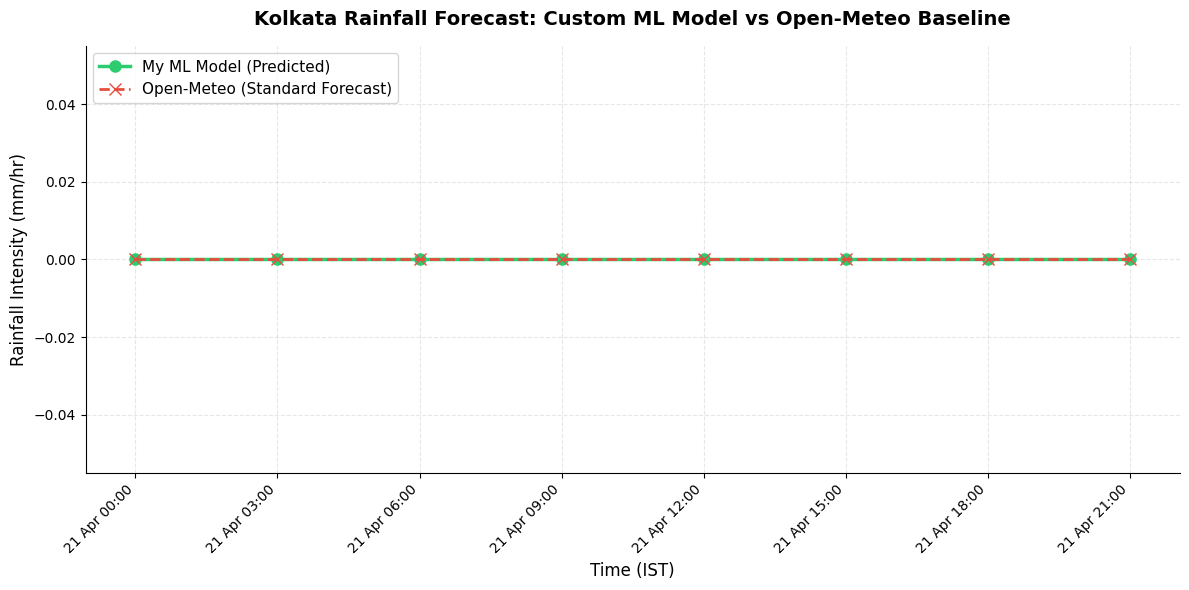

In [ ]:
# ── Cell 8: Graph Model vs Open-Meteo ─────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_forecast_comparison(forecast_df):
    """
    Fetches the raw, un-zeroed Open-Meteo forecast and plots it
    against your ML model's predictions.
    """
    print("Fetching raw Open-Meteo forecast for comparison...")
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude"     : 22.5726,
        "longitude"    : 88.3639,
        "hourly"       : "precipitation",
        "past_days"    : 0,
        "forecast_days": 2,
        "timezone"     : "Asia/Kolkata",
    }

    r = requests.get(url, params=params, timeout=10)
    data = r.json()['hourly']

    # Create Open-Meteo dataframe
    om_df = pd.DataFrame({
        'time_ist': pd.to_datetime(data['time']),
        'om_rain_mm': data['precipitation']
    })

    # Resample Open-Meteo to 3-hourly to perfectly match your ML model's timeline
    om_df = om_df.set_index('time_ist').resample('3h').sum().reset_index()
    om_df['om_rain_mm_hr'] = om_df['om_rain_mm'] / 3.0

    # Merge the two datasets based on the exact IST time slots
    plot_df = pd.merge(forecast_df, om_df, on='time_ist', how='left')

    # ── Plotting ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot your ML Model
    ax.plot(plot_df['time_ist'], plot_df['rain_mm_hr'],
            marker='o', markersize=8, linewidth=2.5,
            color='#2ecc71', label='My ML Model (Predicted)')

    # Plot Open-Meteo
    ax.plot(plot_df['time_ist'], plot_df['om_rain_mm_hr'],
            marker='x', markersize=8, linestyle='--', linewidth=2,
            color='#e74c3c', label='Open-Meteo (Standard Forecast)')

    # Formatting the Graph
    ax.set_title('Kolkata Rainfall Forecast: Custom ML Model vs Open-Meteo Baseline',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Rainfall Intensity (mm/hr)', fontsize=12)
    ax.set_xlabel('Time (IST)', fontsize=12)

    # Format the x-axis to look clean (e.g., "31 Mar 15:00")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
    plt.xticks(rotation=45, ha='right')

    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=11, loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

# Run the plot
plot_forecast_comparison(forecast_df)